In [1]:
import xarray as xr
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
settings_file_path = "../v2_dpa_train_settings.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 476900)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...

In [3]:
ds_train = ds.isel(time=slice(0, 4769 * 90)) #4769 * 80
ds_test = ds.isel(time=slice(4769 * 90, 476900))
ds_train

<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 429210)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 3MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...

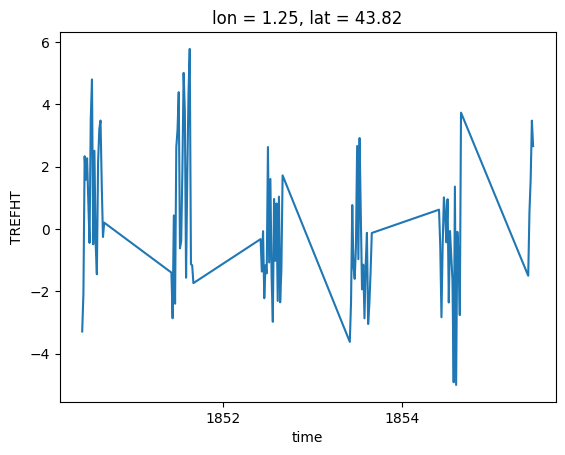

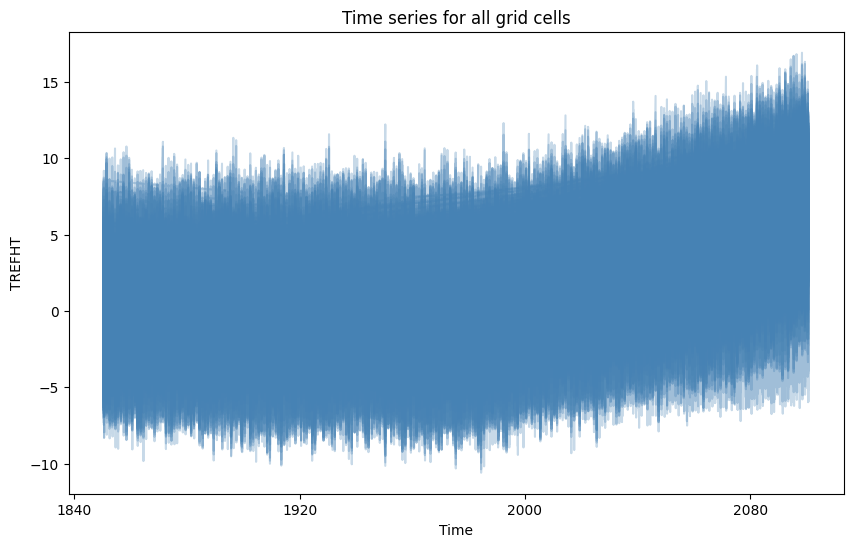

In [8]:
# plot timeseries

ds_train.TREFHT.isel(lat=10, lon=10, time = slice(0,100)).plot()
plt.show()

da=ds_train.TREFHT
plt.figure(figsize=(10, 6))
for i in range(1):#da.sizes["lat"]):
    for j in range(da.sizes["lon"]):
        plt.plot(da["time"], da.isel(lat=i, lon=j), color="steelblue", alpha=0.3)

plt.xlabel("Time")
plt.ylabel(da.name or "Value")
plt.title("Time series for all grid cells")
plt.show()

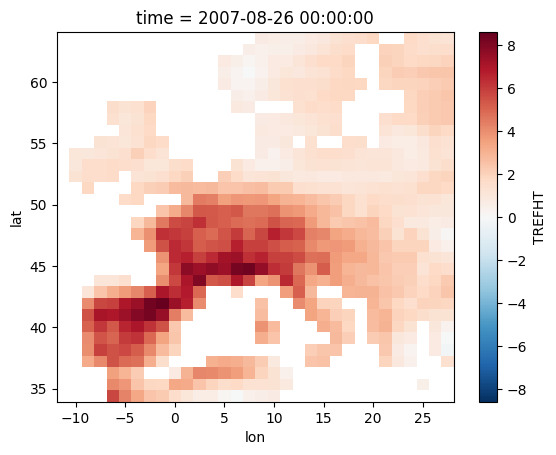

In [27]:
# plot map 

ds_train.TREFHT.isel(time = 3000).plot()

In [3]:
# unstack LE
# spaghetti plot coloring 90/100

#le_masked = ds.TREFHT.where(mask_xr.isel(time=0))

# 'unstack' LE
#arr = le_masked   # shape: (time, lat, lon)

n_ens = 100
n_time = ds.sizes["time"] // n_ens

reshaped = ds.TREFHT.values.reshape(ds.sizes["lat"], ds.sizes["lon"], n_ens, n_time)

In [4]:
#print(reshaped.shape) # shape = (32, 32, 100, 4769)
le_trefht_unstacked = xr.DataArray(
    reshaped,
    dims=("lat", "lon", "ensemble_member", "time"),
    coords={
        "ensemble_member": np.arange(1, n_ens + 1),
        "time": ds.time.isel(time=slice(0,4769)),
        "lat": ds.lat,
        "lon": ds.lon,
    },
    name="TREFHT")

le_trefht_unstacked

<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, ensemble_member: 100, time: 4769)> Size: 2GB
array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
...
           4.547241  ,  3.811615  ],
         [-3.5427246 ,  1.1090393 , -1.4862976 , ...,  6.2487793 ,
           5.2075195 ,  4.183258  ],
         [ 6.745636  ,  7.676361  ,  9.266266  , ..., 10.833099  ,
           9.090546  ,  8.789795  ]],

        [[ 3.6059875 ,  5.5631104 ,  5.5166016 , ...,  5.1252747 ,
           4.1823425 ,  4.4207764 ],
         [-2.7170715 , -1.1324768 ,  1.1658325 , ..., 11.925812  ,
           9.887482  ,  9.009674  ],
         [ 5.8332825 ,  2.5849    ,  0.08828735, ...,  3.868744  ,
           6.082672  ,  8.005707  ],
         ...,
         [ 6.320801  ,  4.8043823 ,  0.17626953, ...,  8.765564  ,
           4.89209   ,  3.567688  ],
         [-4.4461365 ,  0.7754822 , -2.005005  , ...,  6.534485  ,
           5.383026  ,  4.58963   ],
         [ 6.6042786 ,  7.754669  ,  9.350189  , ..., 11.494293  ,
           9.7612    ,  8.645752  ]]]],
      shape=(32, 32, 100, 4769), dtype=float32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5

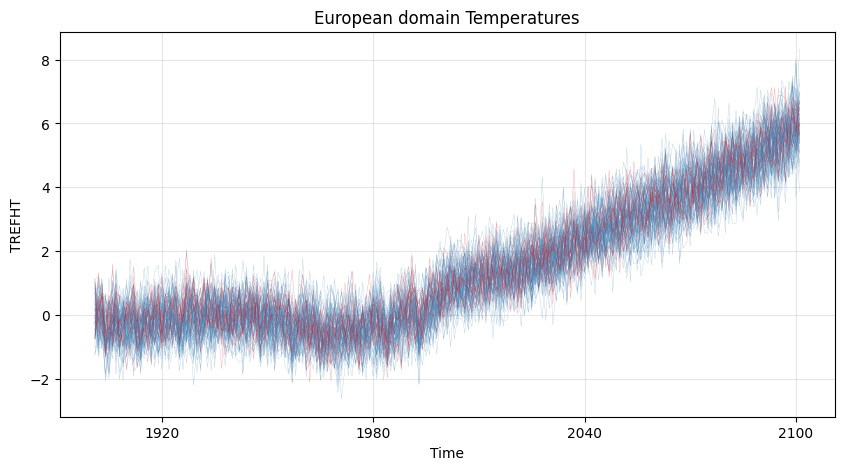

In [29]:
# domain mean

weights = np.cos(np.deg2rad(le_trefht_unstacked.lat))
le_trefht_unstacked_domain_mean = le_trefht_unstacked.weighted(weights).mean(("lat", "lon"))
le_trefht_unstacked_domain_mean

le_trefht_unstacked_domain_mean_yearly = le_trefht_unstacked_domain_mean.resample(time="YE").mean()
plt.figure(figsize=(10, 5))
da = le_trefht_unstacked_domain_mean_yearly.sel(time=slice("1900","2100"))
for i in range(da.sizes["ensemble_member"]):
    if i > 89:
        color = "red"
    else:
        color="steelblue"
    plt.plot(da["time"], da.isel(ensemble_member=i), color=color, alpha=0.5, linewidth=0.2)

plt.xlabel("Time")
plt.ylabel(da.name or "Value")
plt.title("European domain Temperatures")
plt.grid(True, alpha=0.3)
plt.show()

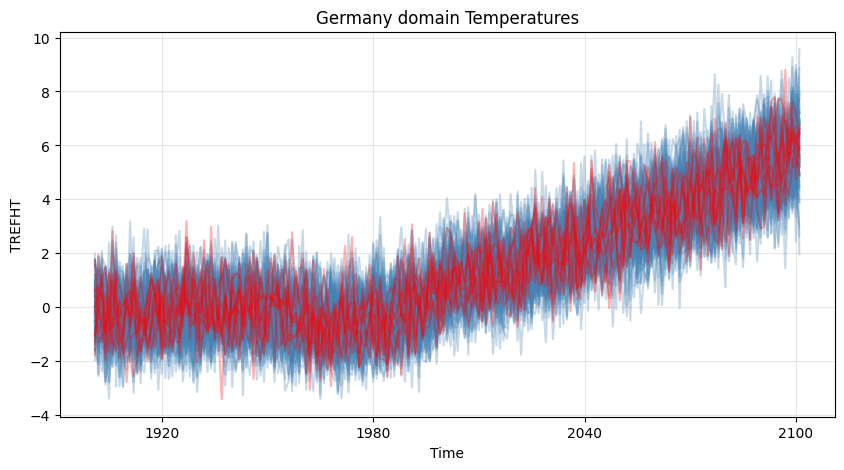

In [30]:
# Germany mean

### Germany ###
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

le_trefht_unstacked_ger = le_trefht_unstacked.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
weights = np.cos(np.deg2rad(le_trefht_unstacked_ger.lat))
le_trefht_unstacked_ger_mean = le_trefht_unstacked_ger.weighted(weights).mean(("lat", "lon"))
le_trefht_unstacked_ger_mean

le_trefht_unstacked_ger_mean_yearly = le_trefht_unstacked_ger_mean.resample(time="YE").mean()
plt.figure(figsize=(10, 5))
da = le_trefht_unstacked_ger_mean_yearly.sel(time=slice("1900","2100"))
for i in range(da.sizes["ensemble_member"]):
    if i > 89:
        color = "red"
    else:
        color="steelblue"
    plt.plot(da["time"], da.isel(ensemble_member=i), color=color, alpha=0.3)

plt.xlabel("Time")
plt.ylabel(da.name or "Value")
plt.title("Germany domain Temperatures")
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# compute grid cell trends

# compute yearly averages
le_yearly = le_trefht_unstacked.resample(time="YE").mean()
print(le_yearly)



<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, ensemble_member: 100, time: 251)> Size: 103MB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             na

<xarray.Dataset> Size: 2MB
Dimensions:               (degree: 2, lat: 32, lon: 32, ensemble_member: 100)
Coordinates:
  * degree                (degree) int64 16B 1 0
  * lat                   (lat) float64 256B 34.4 35.34 36.28 ... 62.67 63.61
  * ensemble_member       (ensemble_member) int64 800B 1 2 3 4 ... 97 98 99 100
  * lon                   (lon) float64 256B -11.25 -10.0 -8.75 ... 26.25 27.5
Data variables:
    polyfit_coefficients  (degree, lat, lon, ensemble_member) float64 2MB nan...

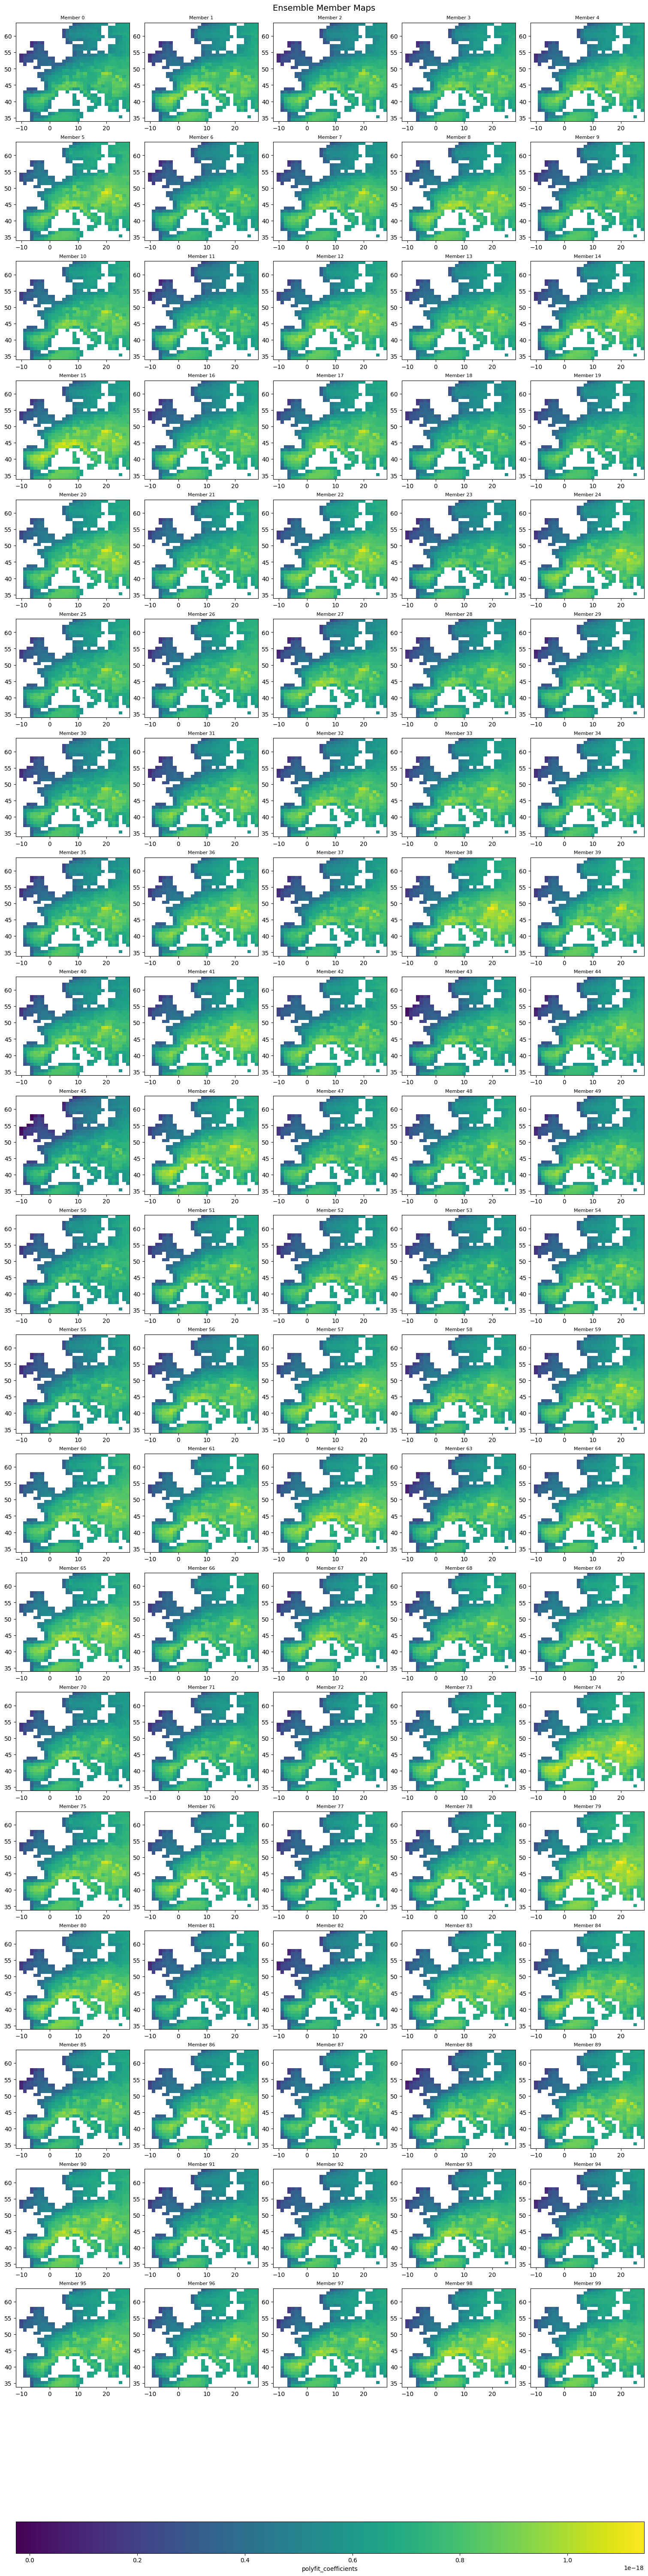

In [13]:

# compute trend
trend = le_yearly.polyfit(dim="time", deg=1)


# extract slope
slope = trend.polyfit_coefficients.sel(degree=1)

da=slope
n_members = da.sizes["ensemble_member"]
ncols = 5
nrows = int(np.ceil(n_members / ncols))

vmin = float(da.min())
vmax = float(da.max())

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 60), 
                         subplot_kw={'projection': None},  # set to None if not using cartopy
                         constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

for i in range(n_members):
    im = da.isel(ensemble_member=i).plot.imshow(
        ax=axes[i],
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )
    axes[i].set_title(f"Member {i}", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
# Hide unused subplots (if any)
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# Add shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label(da.name or "Value")

plt.suptitle("Large Ensemble Temperature trends 1850-2100", fontsize=14)
plt.show()




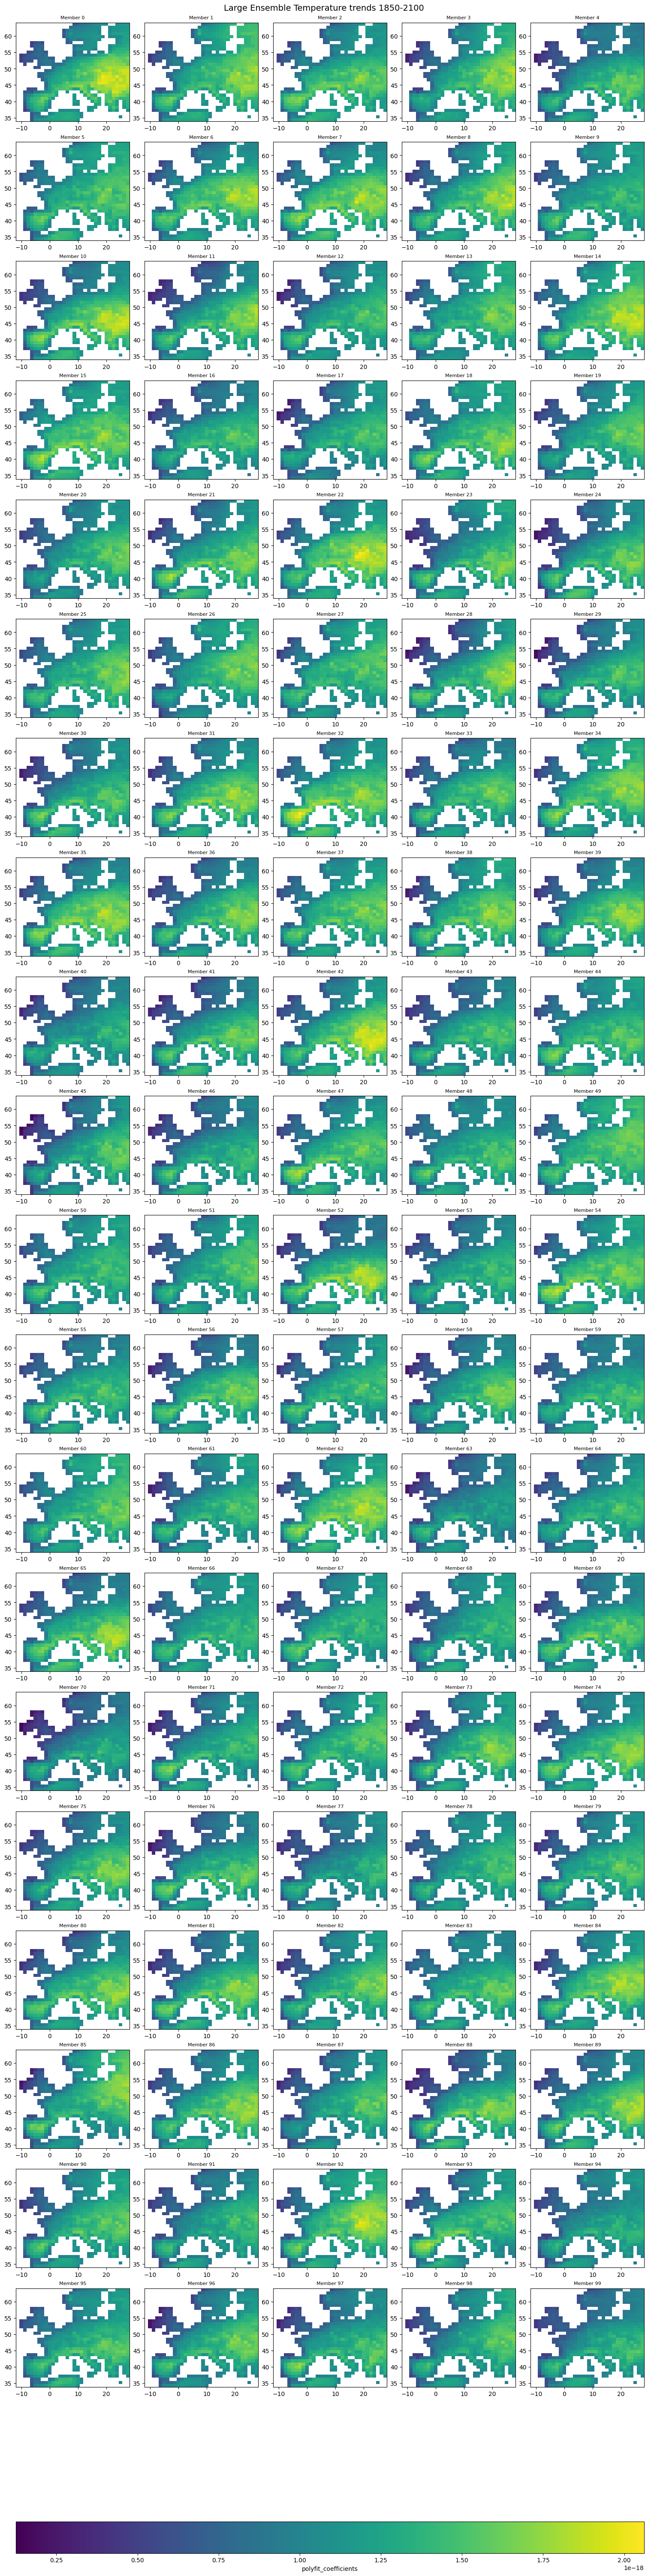

In [15]:
# compute trend
trend = le_yearly.sel(time=slice("1950","2050")).polyfit(dim="time", deg=1)


# extract slope
slope = trend.polyfit_coefficients.sel(degree=1)

da=slope
n_members = da.sizes["ensemble_member"]
ncols = 5
nrows = int(np.ceil(n_members / ncols))

vmin = float(da.min())
vmax = float(da.max())

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 60), 
                         subplot_kw={'projection': None},  # set to None if not using cartopy
                         constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

for i in range(n_members):
    im = da.isel(ensemble_member=i).plot.imshow(
        ax=axes[i],
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )
    axes[i].set_title(f"Member {i}", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
# Hide unused subplots (if any)
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# Add shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label(da.name or "Value")

plt.suptitle("Large Ensemble Temperature trends 1950-2050", fontsize=14)
plt.show()




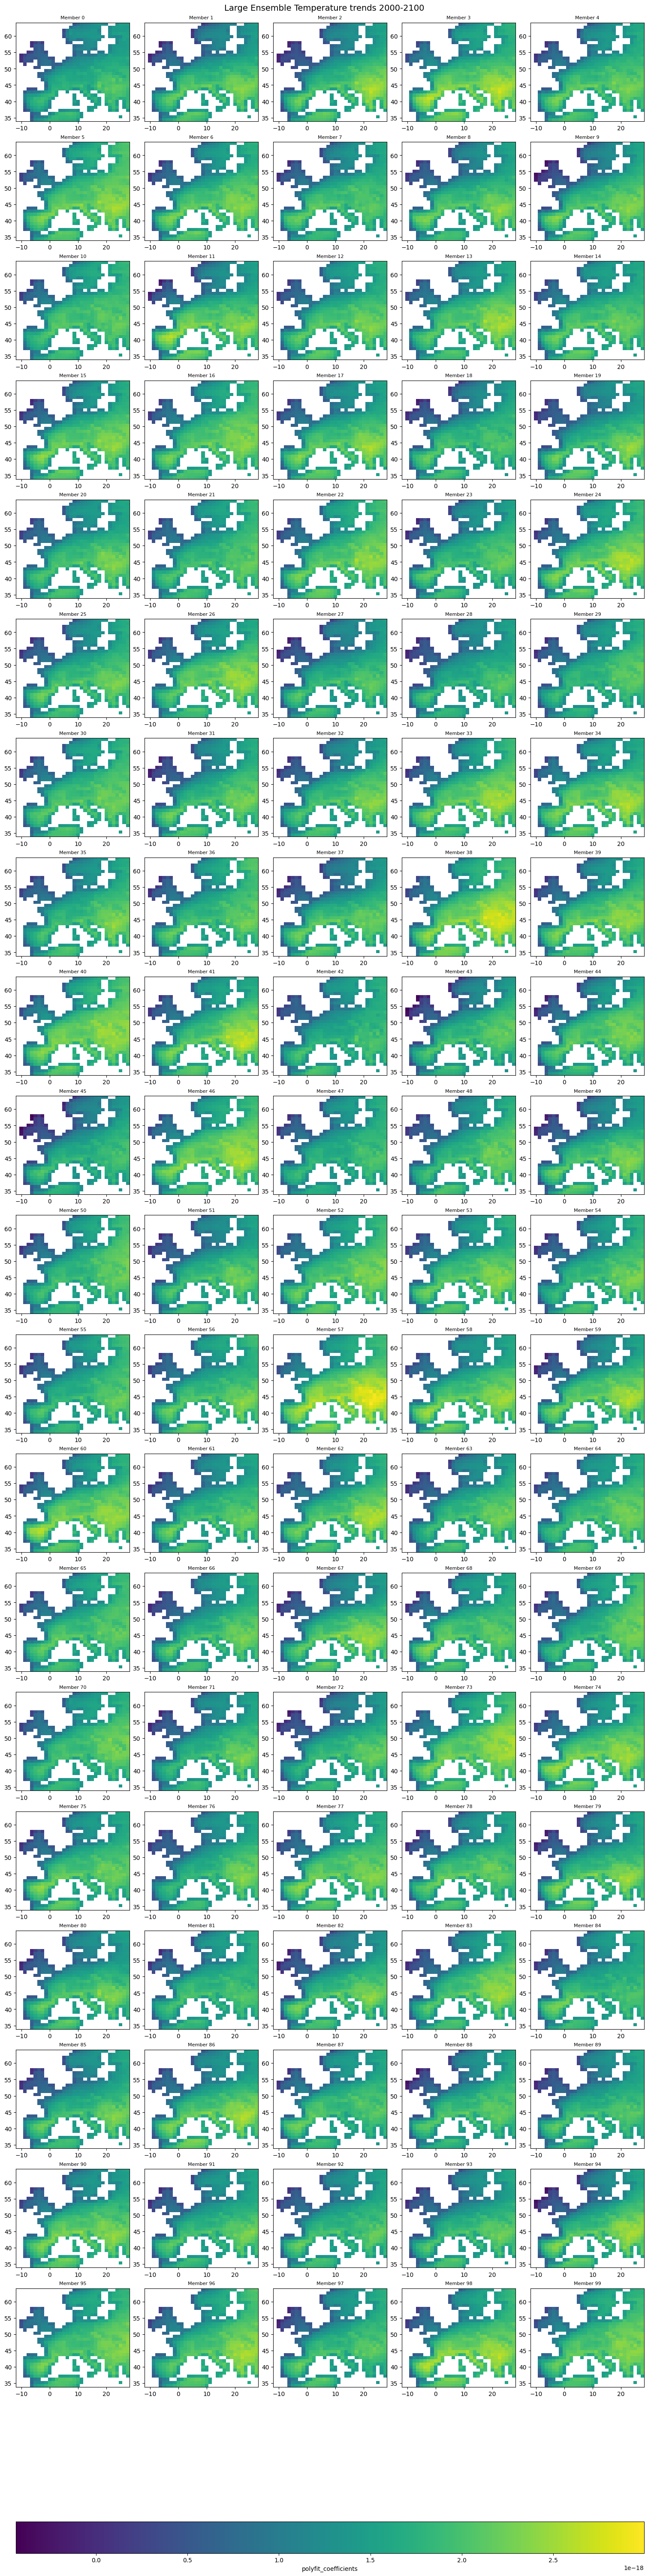

In [16]:
# compute trend
trend = le_yearly.sel(time=slice("2000","2100")).polyfit(dim="time", deg=1)


# extract slope
slope = trend.polyfit_coefficients.sel(degree=1)

da=slope
n_members = da.sizes["ensemble_member"]
ncols = 5
nrows = int(np.ceil(n_members / ncols))

vmin = float(da.min())
vmax = float(da.max())

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 60), 
                         subplot_kw={'projection': None},  # set to None if not using cartopy
                         constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

for i in range(n_members):
    im = da.isel(ensemble_member=i).plot.imshow(
        ax=axes[i],
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )
    axes[i].set_title(f"Member {i}", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
# Hide unused subplots (if any)
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# Add shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label(da.name or "Value")

plt.suptitle("Large Ensemble Temperature trends 2000-2100", fontsize=14)
plt.show()


